<a href="https://colab.research.google.com/github/ayomikun-adekeye/ai-personals/blob/main/PyTorch_Recap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# device agnosticity

device =  "cuda" if torch.cuda.is_available() else "cpu"
print(f"Default device: {device}")

Default device: cpu


**Generate data**

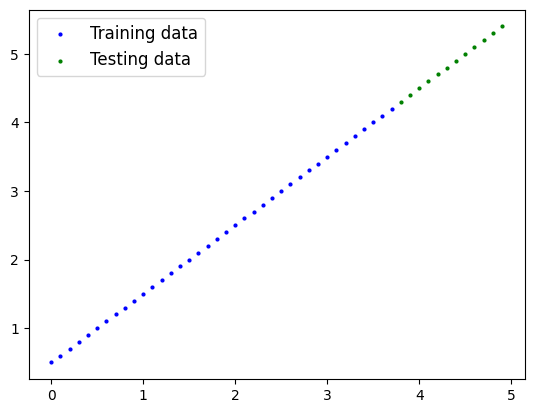

In [ ]:
weight = 1.0 # basically a 1 by 1 weight matrix
bias = 0.5

start, end, step = 0.0, 5, 0.1
X = torch.arange(start, end, step).unsqueeze(dim=1) # wards off errors
Y = weight * X + bias

# train 75%, test 25%
split = round(0.75 * len(X))
x_train, x_test = X[:split], X[split:]
y_train, y_test = Y[:split], Y[split:]

#Don't forget the plot predictions fuction, it was really useful
def plot_preds(train_data=x_train, train_labels=y_train,
                     test_data=x_test, test_labels=y_test,
                     predictions=None):

  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size":12})
  plt.show()

# execute the function to visualize the data
plot_preds()



**The actual model that subclasses nn**

In [ ]:
class LinearRegModel(nn.Module):
  def __init__(self):
    super().__init__()

    # This makes so much sense though, number of nodes at input & output
    self.linear_layer = nn.Linear(in_features= 1, out_features= 1, bias= True)

  def forward(self, x: torch.tensor) -> torch.tensor:
    return self.linear_layer(x)

torch.manual_seed(23)
model_0 = LinearRegModel()
model_0.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.1435]])),
             ('linear_layer.bias', tensor([-0.4223]))])

In [ ]:
next(model_0.parameters()).device, device

(device(type='cpu'), 'cpu')

In [ ]:
import torch.nn as nn
import torch.optim as optim

loss_fn = nn.L1Loss()
optim = optim.SGD(model_0.parameters(), lr= 0.05)

In [ ]:
epochs = 200

for epoch in range(epochs):
  # TRAIN
  model_0.train()
  y_preds= model_0(x_train)
  loss = loss_fn(y_preds, y_train)

  optim.zero_grad()

  loss.backward()
  optim.step()

  # TEST
  model_0.eval()
  with torch.inference_mode():
    test_preds = model_0(x_test)
    test_loss = loss_fn(test_preds, y_test) #test vs ideal always

  # what's happening?
  if epoch % 20 == 0:
    print(f"""
    We're on epoch: {epoch}\n
    Training loss is: {loss}, Test loss is {test_loss}\n\n
    """)




    We're on epoch: 0

    Training loss is: 3.0377197265625, Test loss is 5.444054126739502


    

    We're on epoch: 20

    Training loss is: 0.05983614921569824, Test loss is 0.04595959186553955


    

    We're on epoch: 40

    Training loss is: 0.19151540100574493, Test loss is 0.003798325778916478


    

    We're on epoch: 60

    Training loss is: 0.19408273696899414, Test loss is 0.003798325778916478


    

    We're on epoch: 80

    Training loss is: 0.19408273696899414, Test loss is 0.003798325778916478


    

    We're on epoch: 100

    Training loss is: 0.19408273696899414, Test loss is 0.003798325778916478


    

    We're on epoch: 120

    Training loss is: 0.19408273696899414, Test loss is 0.003798325778916478


    

    We're on epoch: 140

    Training loss is: 0.19408273696899414, Test loss is 0.003798325778916478


    

    We're on epoch: 160

    Training loss is: 0.19408273696899414, Test loss is 0.003798325778916478


    

    We're on epoch: 180

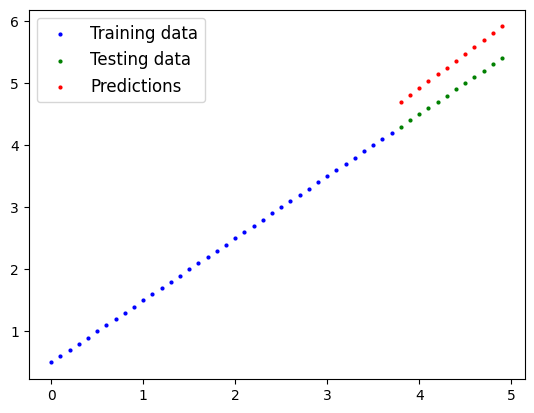

In [ ]:
with torch.inference_mode():
  preds = model_0(x_test)
plot_preds(predictions= preds)

SAVE AND LOAD...